In [1269]:
import pickle
from matplotlib import pyplot as plt
import numpy as np

In [1270]:
seed_id = 0
with open(f'../data/survival_results_{seed_id}.pkl', 'rb') as f:
    results = pickle.load(f)
with open(f'../data/survival_during_{seed_id}.pkl', 'rb') as f:
    during = pickle.load(f)
with open(f'../data/survival_after_run_{seed_id}.pkl', 'rb') as f:
    after = pickle.load(f)

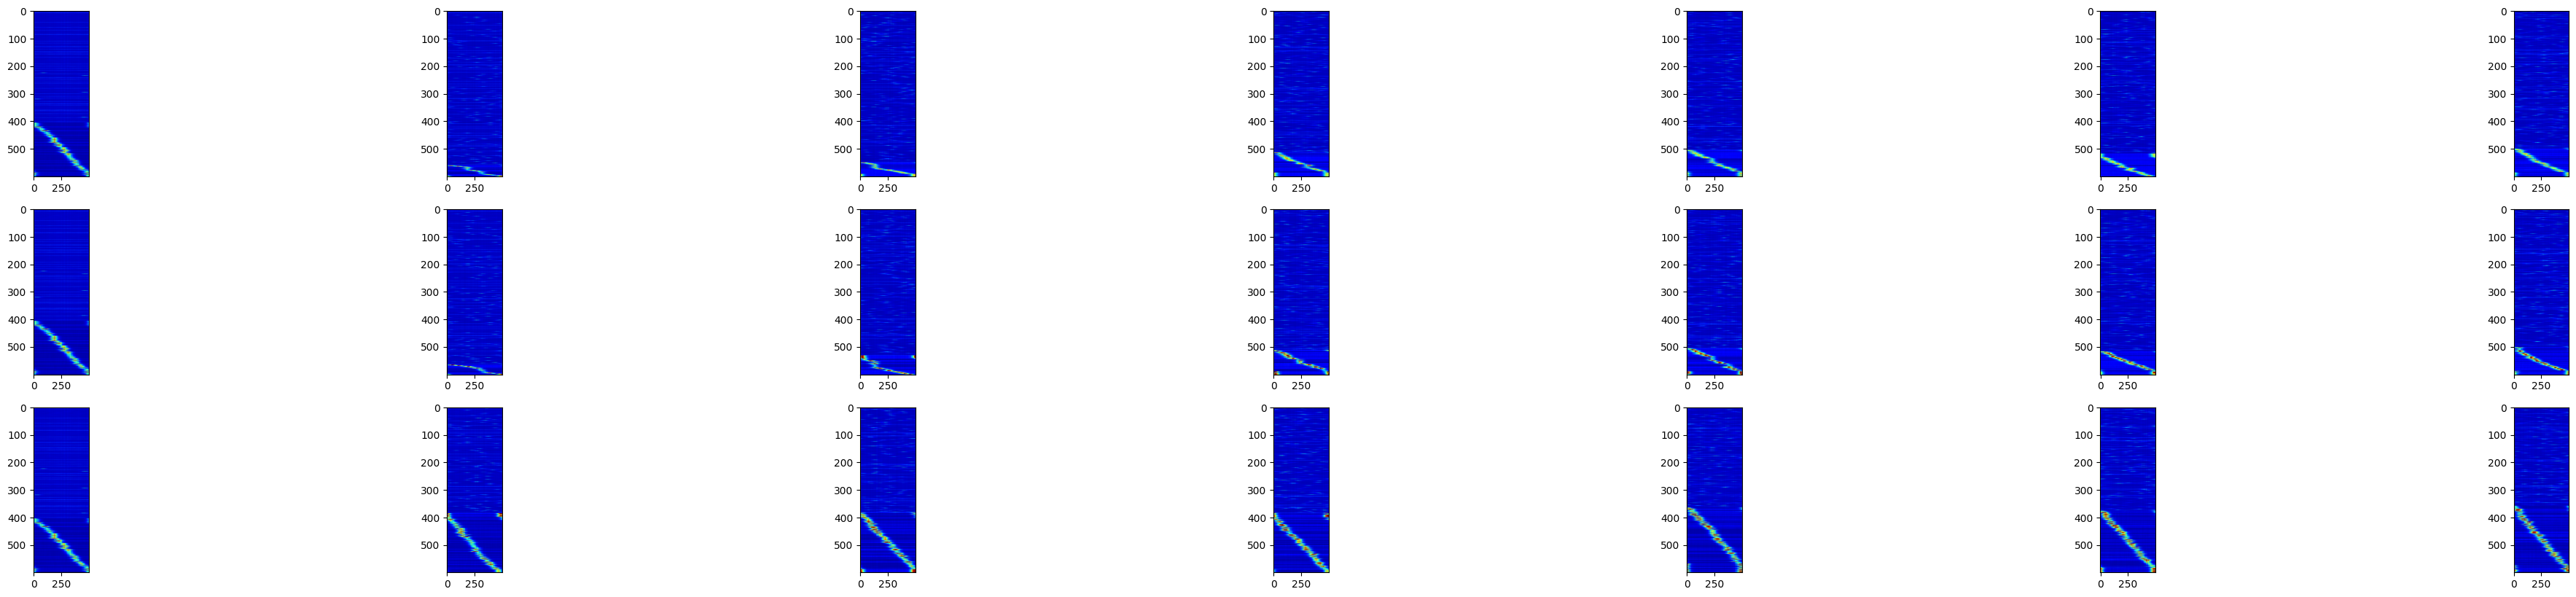

In [1271]:
num = 7
nrows = 3
fig, ax = plt.subplots(ncols=num, nrows=nrows, figsize=(50, 10))

vmin = 0
vmax = 20
cmap = "jet"
masks = []



for i in range(nrows):

    if i == 0:
        data = after
    elif i == 1:
        data = during
    else:
        data = results

    #for j in range(num):
    
        #m = survival[i]['rate_avg'].T[survival[j]['sorting']].max(axis=1) > 25
        #print(m.sum())
    
        #masks.append(m)

    for j in range(num):
    
        rate = data[j]['rate_avg'].T[data[j]['sorting']]
    
        #ax[i].imshow(rate[masks[i]], vmin=vmin, vmax=vmax, cmap=cmap, aspect=5) 
        ax[i, j].imshow(rate, vmin=vmin, vmax=vmax, cmap=cmap, aspect=2.5)
    

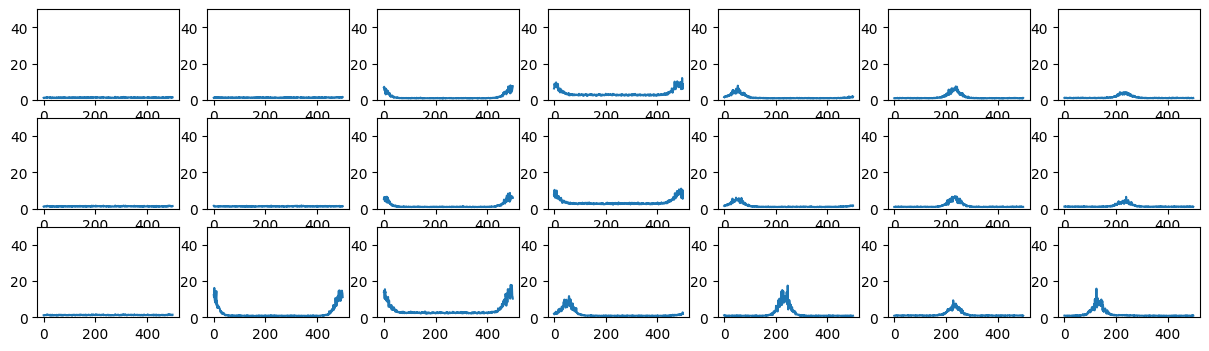

In [1272]:
fig, ax = plt.subplots(nrows=3, ncols=num, figsize=(15, 4))
idx = 122

for i in range(3):
    if i == 0:
        data = after
    elif i == 1:
        data = during
    else:
        data = results
    for j in range(num):

        #ax[i, j].plot(data[j]['rate_avg'].T[data[0]['sorting'][idx]])
        ax[i,j].plot(data[j]['rate_avg'].T[idx])
        ax[i, j].set_ylim(0, 50)
        

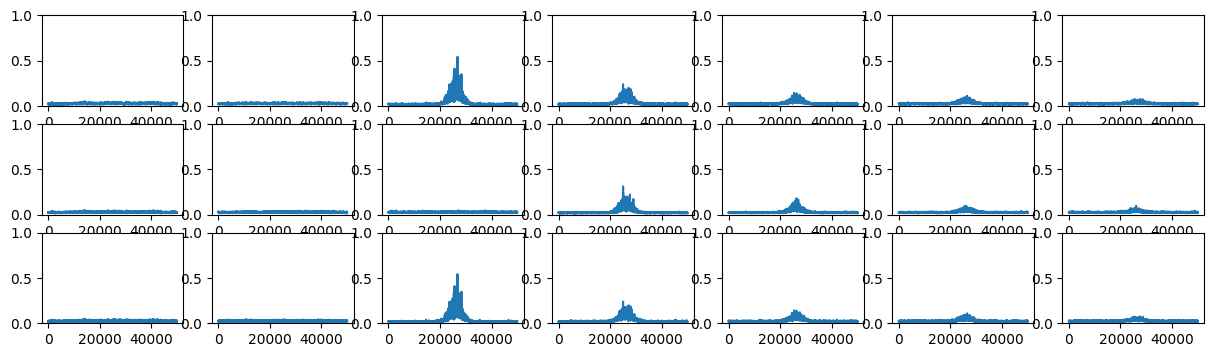

In [1273]:
fig, ax = plt.subplots(nrows=3, ncols=num, figsize=(15, 4))
idx = 11

for i in range(3):
    if i == 0:
        data = after
    if i == 1:
        data = during
    else:
        data = results
    for j in range(num):

        #ax[i, j].plot(data[j]['f'][results[0]['sorting'][idx]])
        ax[i, j].plot(data[j]['f'][idx])
        ax[i, j].set_ylim(0, 1)

        if j >= 1 and i == 1:
            PP_loc = np.where(data[j]['PP_onset'][idx] == 1)[0]
            for loc in PP_loc:
                ax[i, j].axvline(loc)
        

In [1274]:
idx = 193

w = results[4]['w_prox'][idx]
w_after = after[4]['w_prox'][idx]
w_during = during[4]['w_prox'][idx]
w_next = results[4]['w_prox'][idx]

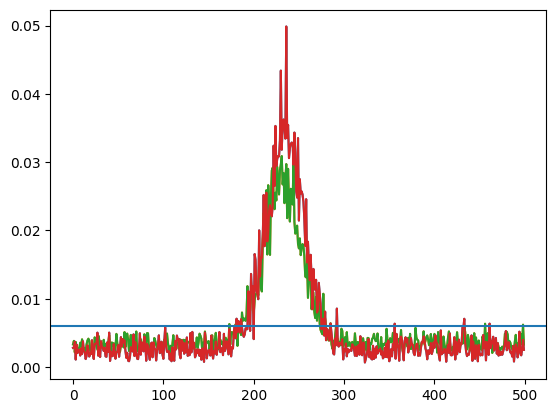

In [1275]:
plt.plot(w)
plt.plot(w_after)
plt.plot(w_during)
plt.plot(w_next)
plt.axhline(3 / 500)

In [1276]:
print(w_after.sum())
print(w.sum())
print(w_during.sum())
print(w_next.sum())
print(np.allclose(w_next, w_during))

2.477 / 500

3.0
3.0
3.0
3.0
False


0.004954

In [1277]:
thres = 10
mask_PC = []
num_PCs = []

num = 7


for i in range(num):
    rates = results[i]['rate_avg'].T.copy()

    mask = rates.max(axis=1) > thres
    mask_PC.append(set(np.where(mask == True)[0].tolist()))
    num_PCs.append(len(mask_PC[i]))

data_model = []

start = 0
for i in range(start, len(mask_PC)):

    if i == start:
        ref = mask_PC[i].copy()
    else:
        ref = mask_PC[i].copy().difference(mask_PC[i-1])
    
    data = []
    for j in range(i, len(mask_PC)):
        ref.intersection_update(mask_PC[j])
        data.append(len(ref))

    data_model.append(data)

new = []
old = []

for i in range(len(data_model)):
    
    new.append(data_model[i][0])
    val = 0
    for j in range(0, i):
        val += data_model[j][i - j]

    old.append(val)
    

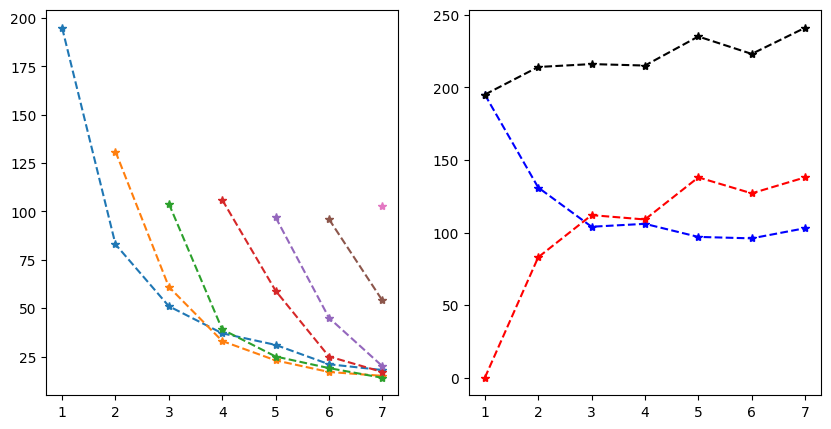

In [1278]:
num_g = num
fig, ax = plt.subplots(ncols=2, figsize=(10,5))

for i, data_ in enumerate(data_model):
    ax[0].plot(np.arange(i + 1, num_g  + 1), data_, marker='*', ls='--')



ax[1].plot(np.arange(1, num_g + 1), new, marker='*', ls='--', color='blue')
ax[1].plot(np.arange(1, num_g + 1), old, marker='*', ls='--', color='red')
ax[1].plot(np.arange(1, num_g + 1), np.array(new) + np.array(old), marker='*', ls='--', color='k') 

In [1280]:
data_model

[[195, 83, 51, 37, 31, 21, 18],
 [131, 61, 33, 23, 17, 15],
 [104, 39, 25, 19, 14],
 [106, 59, 25, 17],
 [97, 45, 20],
 [96, 54],
 [103]]

In [1264]:
import pandas as pd

In [1265]:
df_fig2e = pd.read_excel('data_fig2_magee/41593_2025_1986_MOESM3_ESM.xlsx', sheet_name='Fig2e')[1:].values
df_fig2g = pd.read_excel('data_fig2_magee/41593_2025_1986_MOESM3_ESM.xlsx', sheet_name='Fig2g')

In [1266]:
f_d_1_fig2e = df_fig2e[:, 1:8]
f_d_2_fig2e = df_fig2e[:, 9:]

data_1 = []
data_2 = []

for i, row in enumerate(f_d_1_fig2e):
    data_1.append(row[i:])

for i, row in enumerate(f_d_2_fig2e):
    data_2.append(row[i:])

[748.0 269.0 137.0 97.0 75.0 53.0 48]
[471.0 198.0 98.0 66.0 46.0 35]
[393.0 168.0 104.0 76.0 57]
[384.0 157.0 82.0 60]
[378.0 172.0 121]
[332.0 158]
[333]
[812.0 284.0 168.0 107.0 81.0 61.0 47]
[461.0 177.0 103.0 70.0 54.0 45]
[427.0 157.0 99.0 59.0 43]
[357.0 136.0 91.0 67]
[353.0 164.0 98]
[372.0 147]
[353]


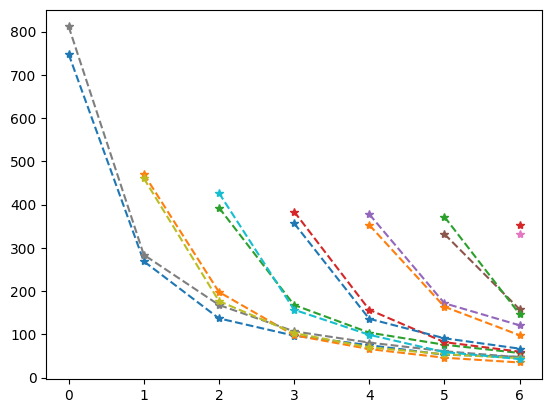

In [1267]:
num = 7
for i, data_ in enumerate(data_1):
    print(data_)
    plt.plot(np.arange(i, num), data_, marker='*', ls='--')

for i, data_ in enumerate(data_2
                         ):
    print(data_)
    plt.plot(np.arange(i, num), data_, marker='*', ls='--')

In [1268]:
new_1 = []
old_1 = []

for i in range(len(data_1)):
    
    new_1.append(data_1[i][0])
    val = 0
    for j in range(0, i):
        val += data_1[j][i - j]

    old_1.append(val)

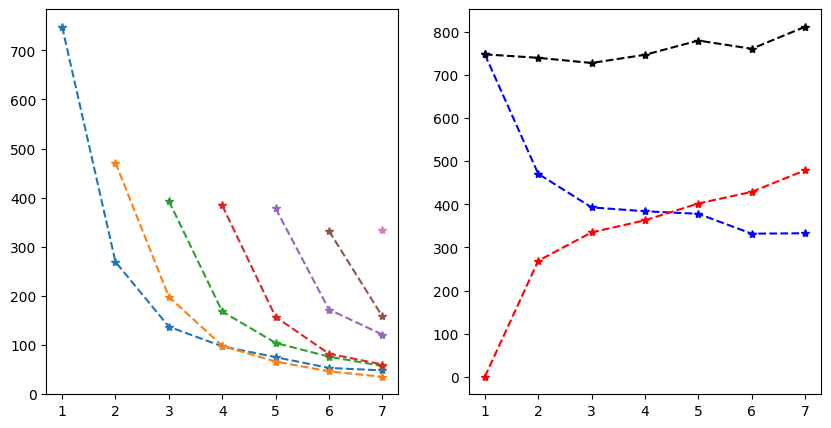

In [1098]:
num = 7
fig, ax = plt.subplots(ncols=2, figsize=(10,5))

for i, data_ in enumerate(data_1):
    ax[0].plot(np.arange(i + 1, num  + 1), data_, marker='*', ls='--')

ax[1].plot(np.arange(1, num + 1), new_1, marker='*', ls='--', color='blue')
ax[1].plot(np.arange(1, num + 1), old_1, marker='*', ls='--', color='red')
ax[1].plot(np.arange(1, num + 1), np.array(new_1) + np.array(old_1), marker='*', ls='--', color='k')

In [1099]:
colors = ['firebrick', 'darkorange', 'chartreuse',  'green', 'cyan', 'blueviolet', 'crimson']

In [1100]:
colors = ['firebrick', 'darkorange', 'chartreuse',  'green', 'cyan', 'blueviolet', 'crimson']
mosaic = """
    AAAAAAAA
    ........
    BBBBCCCC
    BBBBCCCC
    BBBBCCCC
    DDDDEEEE
    DDDDEEEE
    DDDDEEEE
    DDDDEEEE
    """

place_filed_tiles = ['B', 'C']
titles = ['Hippocampal Data', 'Model Data']

place_tiles = ['B', 'C', 'D', 'E']

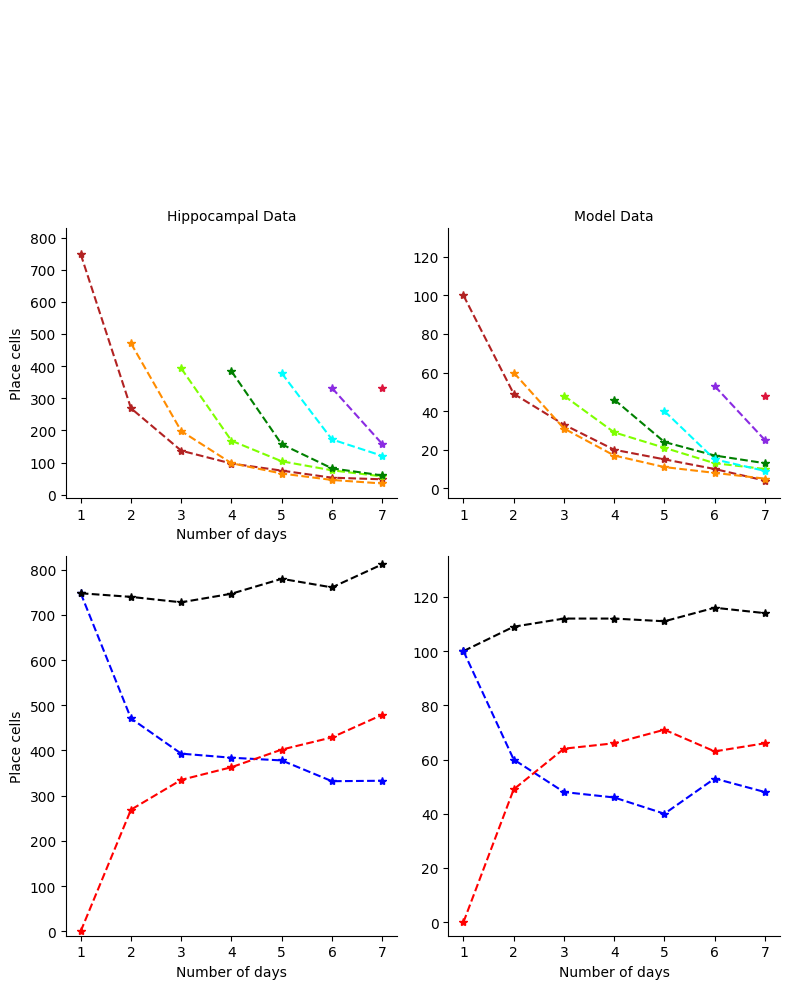

In [1101]:
num = 7
num_data = 8
fig = plt.figure(figsize=(8,10))
ax_dict = fig.subplot_mosaic(mosaic)

for (tile, title) in zip(place_filed_tiles, titles):
    ax_dict[tile].set_title(title, fontsize=10)

for tile in place_tiles:
    ax_dict[tile].spines['top'].set_visible(False)
    ax_dict[tile].spines['right'].set_visible(False)

    
for spine in ax_dict['A'].spines.keys():
    ax_dict['A'].spines[spine].set_visible(False)
ax_dict['A'].set_xticks([])
ax_dict['A'].set_yticks([])
    
ax_dict['B'].set_ylim([-10, 830])
ax_dict['B'].set_ylabel('Place cells')

for i, data_ in enumerate(data_1):
    ax_dict['B'].plot(np.arange(i + 1, num  + 1), data_, marker='*', ls='--', color=colors[i])
ax_dict['B'].set_xticks(np.arange(1, num + 1).tolist())
ax_dict['B'].set_xlabel('Number of days')

ax_dict['C'].set_ylim([-5, 135])

for i, data in enumerate(data_model):
    ax_dict['C'].plot(np.arange(i + 1, num_data), data, marker='*', ls='--', color=colors[i])
ax_dict['C'].set_ylim([-5, 135]) 

ax_dict['D'].set_ylim([-10, 830])

ax_dict['D'].plot(np.arange(1, num + 1), new_1, marker='*', ls='--', color='blue')
ax_dict['D'].plot(np.arange(1, num + 1), old_1, marker='*', ls='--', color='red')
ax_dict['D'].plot(np.arange(1, num + 1), np.array(new_1) + np.array(old_1), marker='*', ls='--', color='k')
ax_dict['D'].set_xticks(np.arange(1, num + 1).tolist())
ax_dict['D'].set_xlabel('Number of days')
ax_dict['D'].set_ylabel('Place cells')


#ax_dict['E'].plot(np.arange(1, num_data), num_PCs[1:], marker='*', ls='--', color='k')
ax_dict['E'].plot(np.arange(1, num_data), np.asarray(new) + np.asarray(old), marker='*', ls='--', color='k')
ax_dict['E'].plot(np.arange(1, num_data), new, marker='*', ls='--', color='blue')
ax_dict['E'].plot(np.arange(1, num_data), old, marker='*', ls='--', color='red')
ax_dict['E'].set_xlabel('Number of days')
ax_dict['E'].set_ylim([-5, 135])

plt.tight_layout()

In [1281]:
val = []
num = 7
for i in range(1, num):
    val.append(np.trace(results[i-1]['rate_avg'] / np.linalg.norm(results[i - 1]['rate_avg']) @ results[i]['rate_avg'].T / np.linalg.norm(results[i]['rate_avg'])))

/var/folders/63/bj4sy42d73zfhb8t5d3xm1jh0000gn/T/ipykernel_69866/729896271.py:4: RuntimeWarning: divide by zero encountered in matmul
  val.append(np.trace(results[i-1]['rate_avg'] / np.linalg.norm(results[i - 1]['rate_avg']) @ results[i]['rate_avg'].T / np.linalg.norm(results[i]['rate_avg'])))
/var/folders/63/bj4sy42d73zfhb8t5d3xm1jh0000gn/T/ipykernel_69866/729896271.py:4: RuntimeWarning: overflow encountered in matmul
  val.append(np.trace(results[i-1]['rate_avg'] / np.linalg.norm(results[i - 1]['rate_avg']) @ results[i]['rate_avg'].T / np.linalg.norm(results[i]['rate_avg'])))
/var/folders/63/bj4sy42d73zfhb8t5d3xm1jh0000gn/T/ipykernel_69866/729896271.py:4: RuntimeWarning: invalid value encountered in matmul
  val.append(np.trace(results[i-1]['rate_avg'] / np.linalg.norm(results[i - 1]['rate_avg']) @ results[i]['rate_avg'].T / np.linalg.norm(results[i]['rate_avg'])))


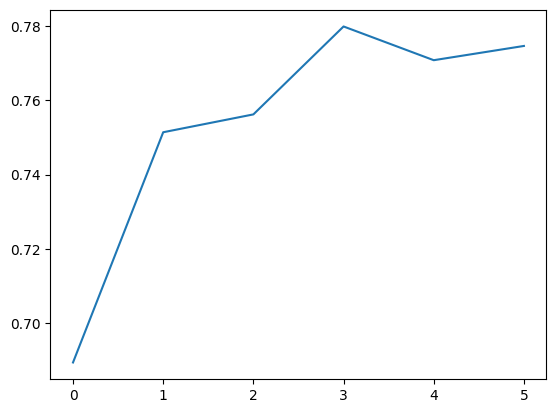

In [1282]:
plt.plot(val)

In [1283]:
for a in ax_dict['A'].spines.keys():
    print(a)

left
right
bottom
top


In [1301]:
rates = []
results[0]['f'].shape

bin_width = 500

steps = int(results[0]['f'].shape[1] / bin_width)


for day in range(num):
    avg_rates = np.zeros((results[0]['f'].shape[0], steps))
    for i in range(steps):
        
        avg_rates[:, i] = results[day]['f'][:, i * bin_width: (i+1)* bin_width].mean(axis=1) * 50 *  1000/ bin_width

    rates.append(avg_rates)
    



In [1367]:
val = []
num = 7
for day in range(1, num):
    val.append(np.trace(rates[0] @ rates[day].T) / np.linalg.norm(rates[day - 1]) / np.linalg.norm(rates[day]))


/var/folders/63/bj4sy42d73zfhb8t5d3xm1jh0000gn/T/ipykernel_69866/3893143004.py:4: RuntimeWarning: divide by zero encountered in matmul
  val.append(np.trace(rates[0] @ rates[day].T) / np.linalg.norm(rates[day - 1]) / np.linalg.norm(rates[day]))
/var/folders/63/bj4sy42d73zfhb8t5d3xm1jh0000gn/T/ipykernel_69866/3893143004.py:4: RuntimeWarning: overflow encountered in matmul
  val.append(np.trace(rates[0] @ rates[day].T) / np.linalg.norm(rates[day - 1]) / np.linalg.norm(rates[day]))
/var/folders/63/bj4sy42d73zfhb8t5d3xm1jh0000gn/T/ipykernel_69866/3893143004.py:4: RuntimeWarning: invalid value encountered in matmul
  val.append(np.trace(rates[0] @ rates[day].T) / np.linalg.norm(rates[day - 1]) / np.linalg.norm(rates[day]))


(0.0, 1.0)

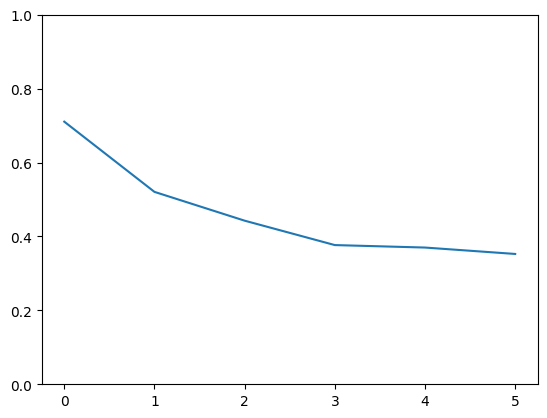

In [1368]:
plt.plot(val)
plt.ylim(0,1)


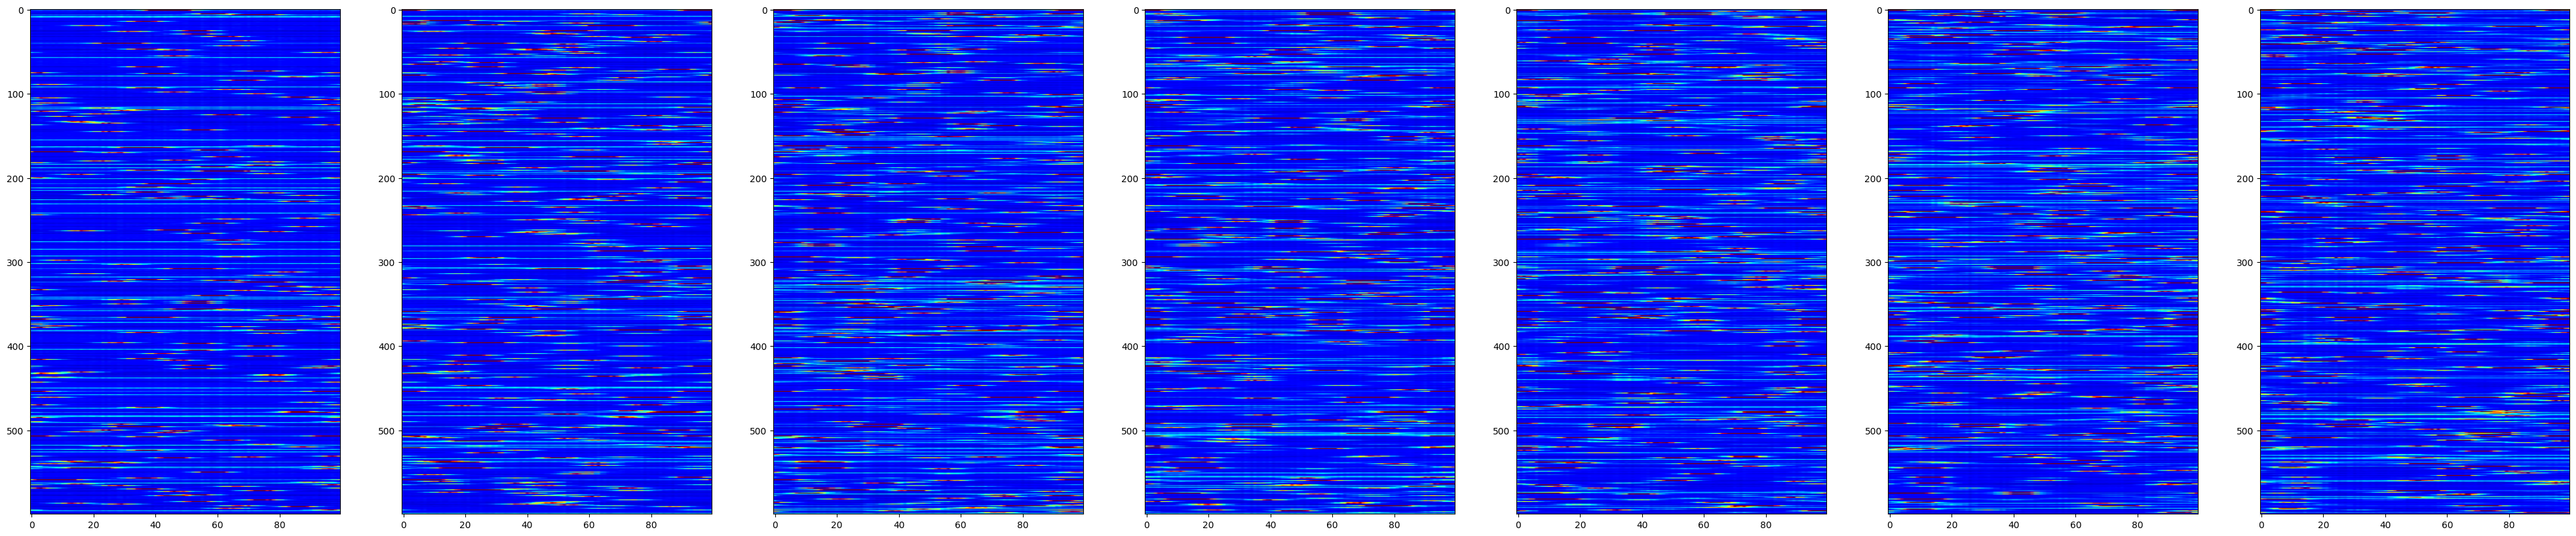

In [1309]:
num = 7
nrows = 1
fig, ax = plt.subplots(ncols=num, nrows=nrows, figsize=(50, 10))

vmin = 0
vmax = 20
cmap = "jet"
masks = []



for j in range(num):
    

    
        #ax[i].imshow(rate[masks[i]], vmin=vmin, vmax=vmax, cmap=cmap, aspect=5) 
    ax[j].imshow(rates[j], vmin=vmin, vmax=vmax, cmap=cmap, aspect='auto')


In [1334]:
num_days = 7
num_seed = 6

data_model_days = []
new_days = []
old_days= []

rates_days = []



for seed_id in range(0, num_seed):
    with open(f'../data/survival_results_{seed_id}.pkl', 'rb') as f:
        results = pickle.load(f)

    thres = 10
    mask_PC = []
    num_PCs = []

    num = 7


    for i in range(num):
        rates = results[i]['rate_avg'].T.copy()

        mask = rates.max(axis=1) > thres
        mask_PC.append(set(np.where(mask == True)[0].tolist()))
        num_PCs.append(len(mask_PC[i]))

    data_model = []

    start = 0
    for i in range(start, len(mask_PC)):

        if i == start:
            ref = mask_PC[i].copy()
        else:
            ref = mask_PC[i].copy().difference(mask_PC[i-1])
    
        data = []
        for j in range(i, len(mask_PC)):
            ref.intersection_update(mask_PC[j])
            data.append(len(ref))

        data_model.append(data)

    new = []
    old = []

    for i in range(len(data_model)):
    
        new.append(data_model[i][0])
        val = 0
        for j in range(0, i):
            val += data_model[j][i - j]

        old.append(val)

    data_model_days.append(data_model)

    new_days.append(new)
    old_days.append(old)

    bin_width = 500

    steps = int(results[0]['f'].shape[1] / bin_width)

    rates = []
    for day in range(num):
        avg_rates = np.zeros((results[0]['f'].shape[0], steps))
        for i in range(steps):     
            avg_rates[:, i] = results[day]['f'][:, i * bin_width: (i+1)* bin_width].mean(axis=1) * 50 *  1000/ bin_width
    
        rates.append(avg_rates)

    rates_days.append(rates)

In [1441]:
from scipy.stats import pearsonr

angles_days = []
num = 7
for i in range(num_seed - 1):
    rates = rates_days[i]
    angles = []
    for day in range(0, num):
        #angles.append(np.trace(rates[0] @ rates[day].T) / np.linalg.norm(rates[0]) / np.linalg.norm(rates[day]))
        angles.append(pearsonr(rates[0].flatten(), rates[day].flatten())[0])

    angles_days.append(angles)

angles_diff_days = []
num = 7
for i in range(num_seed - 1):
    rates = rates_days[i]
    angles = []
    for day in range(1, num):
        #angles.append(np.trace(rates[day - 1] @ rates[day].T) / np.linalg.norm(rates[day - 1]) / np.linalg.norm(rates[day]))
        angles.append(pearsonr(rates[day - 1].flatten(), rates[day].flatten())[0])

    angles_diff_days.append(angles)

In [1442]:
angles_days[0][0][0]

IndexError: invalid index to scalar variable.

In [1443]:
data_model_avg = []
data_model_std = []

for i in range(num_days):
    combination = []
    for j in range(5):
        combination.append(data_model_days[j][i])

    combination = np.asarray(combination)

    data_model_avg.append(combination.mean(axis=0))
    data_model_std.append(combination.std(axis=0))

In [1444]:
new_days = np.asarray(new_days)
old_days = np.asarray(old_days)
rates_days = np.asarray(rates_days)
angles_days = np.asarray(angles_days)

In [1445]:
angles_days

array([[1.        , 0.47993353, 0.29064707, 0.17998526, 0.12416869,
        0.08601495, 0.04942491],
       [1.        , 0.4233234 , 0.24155536, 0.13183613, 0.09136143,
        0.04715125, 0.00595588],
       [1.        , 0.48370114, 0.29397697, 0.14969924, 0.06206965,
        0.02470986, 0.01576164],
       [1.        , 0.46705311, 0.30793293, 0.17331411, 0.12044206,
        0.06675962, 0.02155581],
       [1.        , 0.50216992, 0.30120024, 0.17858135, 0.10123312,
        0.07415511, 0.03813564]])

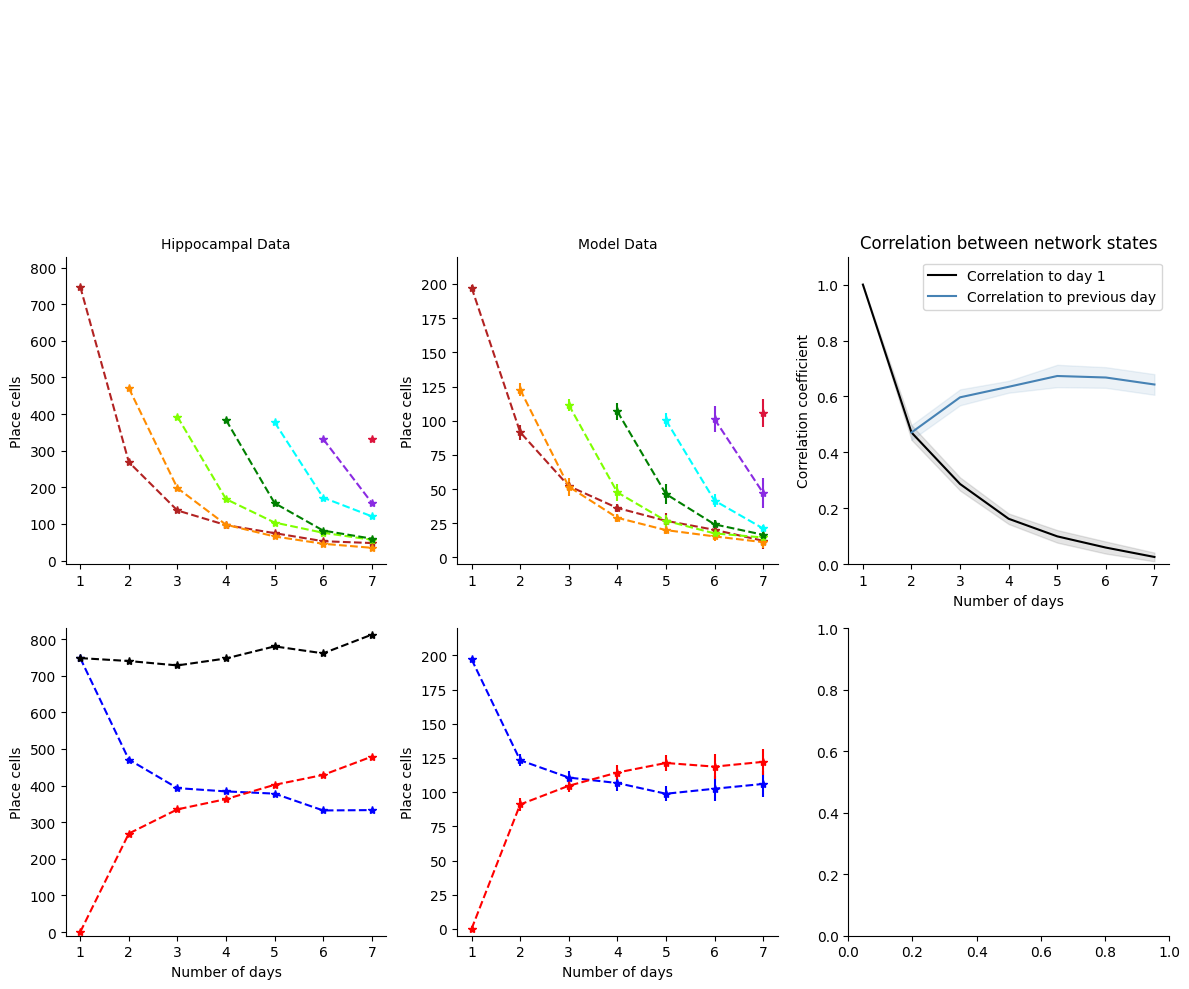

In [1459]:
colors = ['firebrick', 'darkorange', 'chartreuse',  'green', 'cyan', 'blueviolet', 'crimson']
mosaic = """
    AAAAAAAAAAAA
    ............
    BBBBCCCCFFFF
    BBBBCCCCFFFF
    BBBBCCCCFFFF
    DDDDEEEEGGGG
    DDDDEEEEGGGG
    DDDDEEEEGGGG
    """


place_filed_tiles = ['B', 'C']
titles = ['Hippocampal Data', 'Model Data']

place_tiles = ['B', 'C', 'D', 'E', 'F', 'G']

num = 7
num_data = 8
ylim_model = [-5, 220]

fig = plt.figure(figsize=(12,10))
ax_dict = fig.subplot_mosaic(mosaic)

for (tile, title) in zip(place_filed_tiles, titles):
    ax_dict[tile].set_title(title, fontsize=10)

for tile in place_tiles:
    ax_dict[tile].spines['top'].set_visible(False)
    ax_dict[tile].spines['right'].set_visible(False)

    
for spine in ax_dict['A'].spines.keys():
    ax_dict['A'].spines[spine].set_visible(False)
ax_dict['A'].set_xticks([])
ax_dict['A'].set_yticks([])
    
ax_dict['B'].set_ylim([-10, 830])
ax_dict['B'].set_ylabel('Place cells')

for i, data_ in enumerate(data_1):
    ax_dict['B'].plot(np.arange(i + 1, num  + 1), data_, marker='*', ls='--', color=colors[i])
ax_dict['B'].set_xticks(np.arange(1, num + 1).tolist())

ax_dict['C'].set_ylim(ylim_model)

for i, data in enumerate(data_model_avg):
    ax_dict['C'].errorbar(np.arange(i + 1, num_data), data, data_model_std[i], marker='*', ls='--', color=colors[i])
ax_dict['C'].set_ylim(ylim_model)
ax_dict['C'].set_ylabel('Place cells')

ax_dict['D'].set_ylim([-10, 830])

ax_dict['D'].plot(np.arange(1, num + 1), new_1, marker='*', ls='--', color='blue')
ax_dict['D'].plot(np.arange(1, num + 1), old_1, marker='*', ls='--', color='red')
ax_dict['D'].plot(np.arange(1, num + 1), np.array(new_1) + np.array(old_1), marker='*', ls='--', color='k')
ax_dict['D'].set_xticks(np.arange(1, num + 1).tolist())
ax_dict['D'].set_xlabel('Number of days')
ax_dict['D'].set_ylabel('Place cells')


#ax_dict['E'].plot(np.arange(1, num_data), num_PCs[1:], marker='*', ls='--', color='k')
ax_dict['E'].errorbar(np.arange(1, num_days + 1), np.mean(new_days, axis=0),  np.std(new_days, axis=0), marker='*', c='blue', ls='--')
ax_dict['E'].errorbar(np.arange(1, num_days + 1), np.mean(old_days, axis=0), np.std(new_days, axis=0), c='red', ls='--', marker='*')

ax_dict['E'].set_xlabel('Number of days')
ax_dict['E'].set_ylabel('Place cells')
ax_dict['E'].set_ylim(ylim_model)

ax_dict['F'].set_title('Correlation between network states')
ax_dict['F'].plot(np.arange(1, 8), np.mean(angles_days, axis=0), c='k', label='Correlation to day 1')
ax_dict['F'].fill_between(np.arange(1, 8), np.mean(angles_days, axis=0) - np.std(angles_days, axis=0), np.mean(angles_days, axis=0) + np.std(angles_days, axis=0), color='k', alpha=0.1)
ax_dict['F'].plot(np.arange(2, 8), np.mean(angles_diff_days, axis=0), c='steelblue', label='Correlation to previous day')
ax_dict['F'].fill_between(np.arange(2, 8), np.mean(angles_diff_days, axis=0) - np.std(angles_diff_days, axis=0), np.mean(angles_diff_days, axis=0) + np.std(angles_diff_days, axis=0), color='steelblue', alpha=0.1)
ax_dict['F'].set_ylim([0., 1.1])
ax_dict['F'].set_ylabel('Correlation coefficient')
ax_dict['F'].set_xlabel('Number of days')
ax_dict['F'].legend()

plt.tight_layout()

In [1404]:
np.dot(rates_days[0][0].flatten(), rates_days[0][0].flatten()) / np.linalg.norm(rates_days[0][0].flatten()) / np.linalg.norm(rates_days[0][0].flatten())

np.float64(1.0000000000000002)

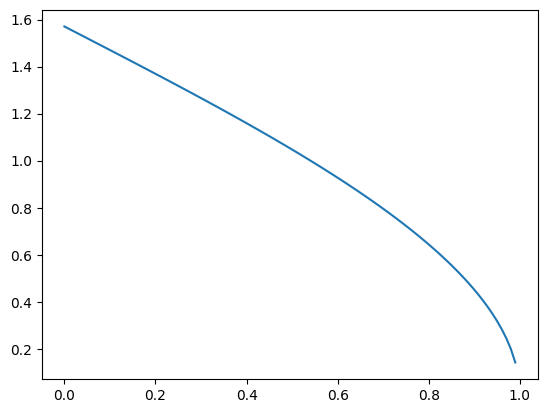

In [1398]:
np.dot(rates_days[0][0].flatten(), rates_days[0][0].flatten()) / np.linalg.norm(rates_days[0][0].flatten()) / np.linalg.norm(rates_days[0][0].flatten())

In [1380]:
a = np.random.poisson(3.75, 10000)

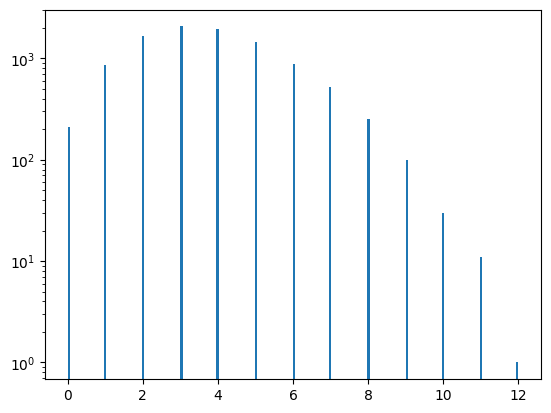

In [1381]:
plt.hist(a, bins=200)
plt.yscale('log')

In [1379]:
a.mean()

np.float64(3.672414708573049)

In [1457]:
U, S, V = np.linalg.svd(rates_days[0][0] @ rates_days[0][1].T)

/var/folders/63/bj4sy42d73zfhb8t5d3xm1jh0000gn/T/ipykernel_69866/3135715515.py:1: RuntimeWarning: divide by zero encountered in matmul
  U, S, V = np.linalg.svd(rates_days[0][0] @ rates_days[0][1].T)
/var/folders/63/bj4sy42d73zfhb8t5d3xm1jh0000gn/T/ipykernel_69866/3135715515.py:1: RuntimeWarning: overflow encountered in matmul
  U, S, V = np.linalg.svd(rates_days[0][0] @ rates_days[0][1].T)
/var/folders/63/bj4sy42d73zfhb8t5d3xm1jh0000gn/T/ipykernel_69866/3135715515.py:1: RuntimeWarning: invalid value encountered in matmul
  U, S, V = np.linalg.svd(rates_days[0][0] @ rates_days[0][1].T)


In [1458]:
S

array([8.69324123e+05, 1.42266755e+05, 1.24132238e+05, 1.07776309e+05,
       8.47923668e+04, 6.06241678e+04, 5.54623997e+04, 3.73272868e+04,
       3.15387572e+04, 2.01491840e+04, 1.48266575e+04, 7.11342018e+03,
       6.19690772e+03, 3.18105705e+03, 2.65943753e+03, 1.22486372e+03,
       1.10187439e+03, 4.93433744e+02, 4.06993170e+02, 1.96475715e+02,
       1.34611241e+02, 5.34200637e+01, 5.21143639e+01, 2.72355428e+01,
       1.90380316e+01, 1.84525819e+01, 1.42163925e+01, 1.18125520e+01,
       1.04441023e+01, 9.71867923e+00, 8.16343924e+00, 7.87610898e+00,
       7.34988967e+00, 7.02140844e+00, 6.30998076e+00, 6.20257916e+00,
       6.11119093e+00, 5.58061698e+00, 5.12849458e+00, 4.97625034e+00,
       4.78395378e+00, 4.51311859e+00, 4.39515584e+00, 4.19106263e+00,
       3.95589092e+00, 3.65137191e+00, 3.59817835e+00, 3.51837835e+00,
       3.37331955e+00, 3.22672236e+00, 3.05275387e+00, 2.88706095e+00,
       2.76529748e+00, 2.72666842e+00, 2.67683760e+00, 2.48434393e+00,
      